In [9]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf

In [11]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense

In [13]:
np.random.seed(180)
tf.random.set_seed(180)

In [15]:
people=fetch_lfw_people(min_faces_per_person=20,resize=0.7)
print(people.data.shape)
print(people.target.shape)
image_shape=people.images[0].shape

(3023, 5655)
(3023,)


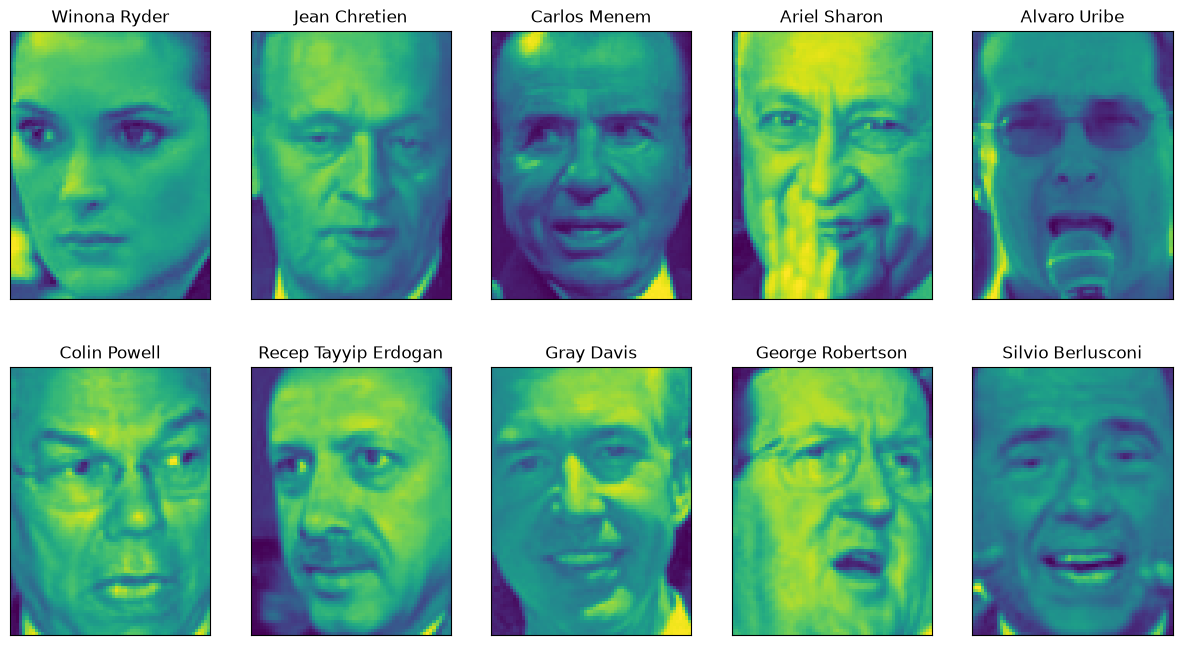

In [16]:
fix,axes=plt.subplots(2,5,figsize=(15,8),subplot_kw={'xticks':(),'yticks':()})
for target,image,ax in zip(people.target,people.images,axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target])
plt.show()

In [18]:
x_train,x_test,y_train,y_test=train_test_split(people.data,people.target,test_size=0.2,random_state=20)
y_train=y_train.astype(int)
y_test=y_test.astype(int)
batch_size=len(x_train)
print(x_train.shape,y_train.shape,y_test.shape)
print("people.images.shape:{}".format(people.images.shape))
print("number of classes:{}".format(len(people.target_names)))

(2418, 5655) (2418,) (605,)
people.images.shape:(3023, 87, 65)
number of classes:62


In [20]:
count=np.bincount(people.target)
for i,(count,name) in enumerate(zip(count,people.target_names)):
    print("{0:25}{1:3}".format(name,count),end=" ")
    if(i+1)%3==0:
        print()

Alejandro Toledo          39 Alvaro Uribe              35 Amelie Mauresmo           21 
Andre Agassi              36 Angelina Jolie            20 Ariel Sharon              77 
Arnold Schwarzenegger     42 Atal Bihari Vajpayee      24 Bill Clinton              29 
Carlos Menem              21 Colin Powell             236 David Beckham             31 
Donald Rumsfeld          121 George Robertson          22 George W Bush            530 
Gerhard Schroeder        109 Gloria Macapagal Arroyo   44 Gray Davis                26 
Guillermo Coria           30 Hamid Karzai              22 Hans Blix                 39 
Hugo Chavez               71 Igor Ivanov               20 Jack Straw                28 
Jacques Chirac            52 Jean Chretien             55 Jennifer Aniston          21 
Jennifer Capriati         42 Jennifer Lopez            21 Jeremy Greenstock         24 
Jiang Zemin               20 John Ashcroft             53 John Negroponte           31 
Jose Maria Aznar          23 Jua

In [21]:
mask=np.zeros(people.target.shape,dtype=np.bool_)
for target in np.unique(people.target):
    mask[np.where(people.target==target)[0][:50]]=True
x_people=people.data[mask]
y_people=people.target[mask]
x_people=x_people/255.0

Test set score of 1-nn:0.22


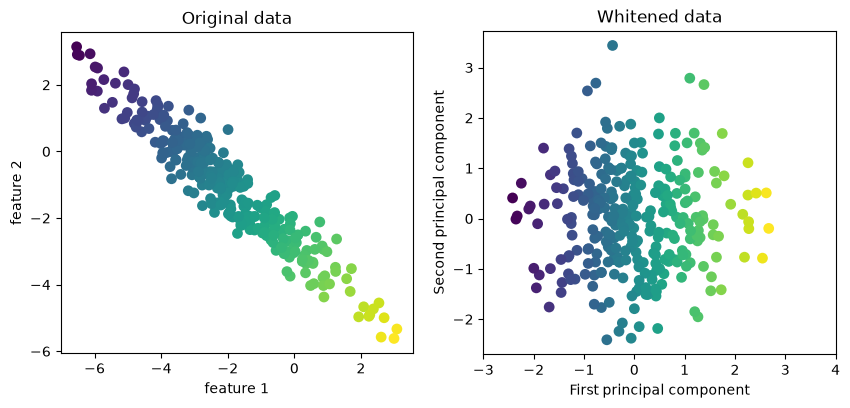

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x_people,y_people,stratify=y_people,random_state=0)
knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train,y_train)
print("Test set score of 1-nn:{:.2f}".format(knn.score(x_test,y_test)))
mglearn.plots.plot_pca_whitening()
plt.show()

In [24]:
pca=PCA(n_components=100,whiten=True,random_state=0).fit(x_train)
x_train_pca=pca.transform(x_train)
x_test_pca=pca.transform(x_test)
print("x_train_pca.shape:{}".format(x_train_pca.shape))
knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train_pca,y_train)
print("Test set accuracy:{:.2f}".format(knn.score(x_test_pca,y_test)))
print("pca.components_.shape:{}".format(pca.components_.shape))

x_train_pca.shape:(1547, 100)
Test set accuracy:0.30
pca.components_.shape:(100, 5655)


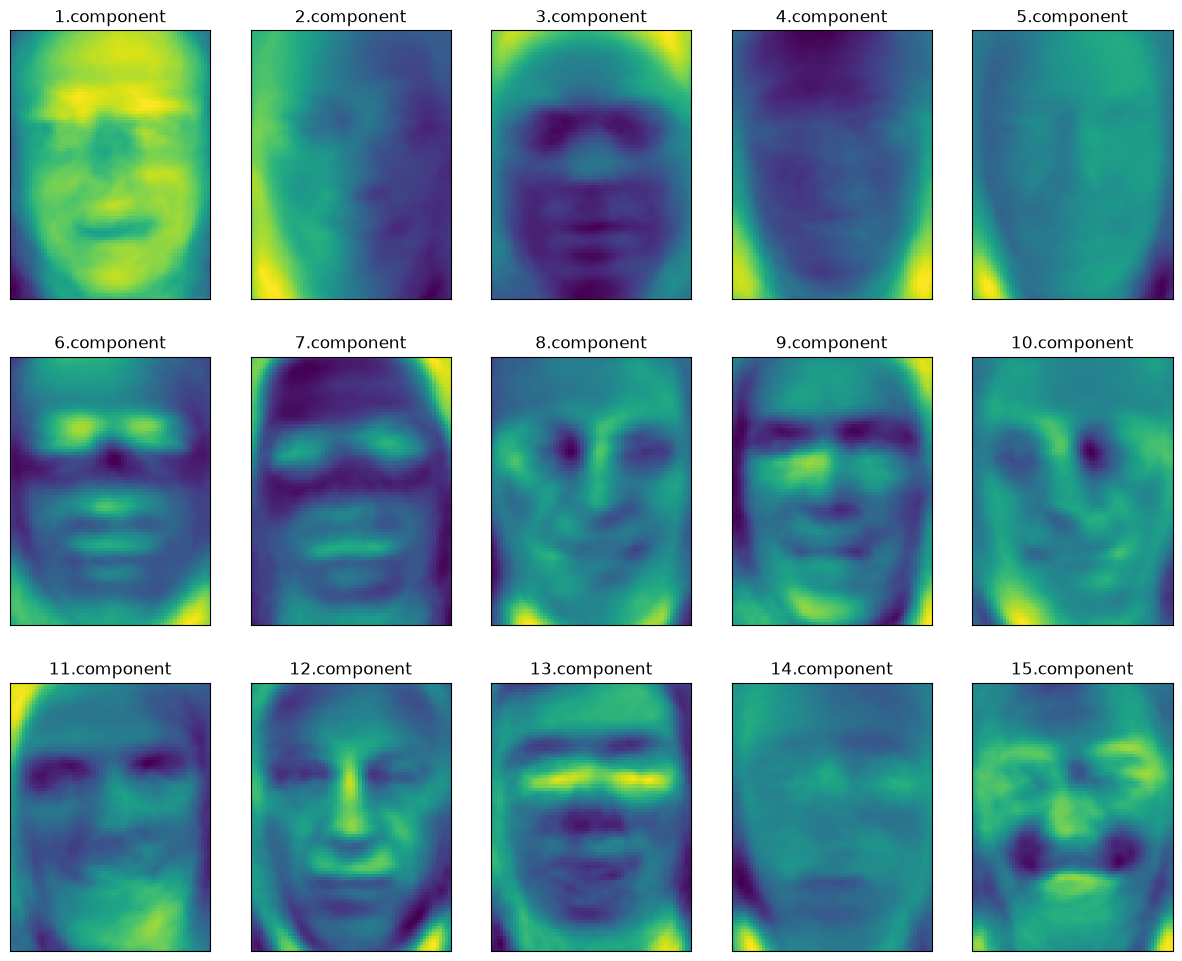

In [27]:
fix,axes=plt.subplots(3,5,figsize=(15,12),subplot_kw={'xticks':(),'yticks':()})
for i,(component,ax) in enumerate(zip(pca.components_,axes.ravel())):
    ax.imshow(component.reshape(image_shape),cmap='viridis')
    ax.set_title("{}.component".format(i+1)
                )
plt.show()

In [28]:
scaler=MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train_pca)
x_test_scaled=scaler.transform(x_test_pca)

In [30]:
model=Sequential([Input(shape=(100,)),Dense(300,activation='relu'),Dense(100,activation='relu'),Dense(len(np.unique(y_train)),activation='softmax')])

In [31]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(x_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False,verbose=1)
loss,accuracy=model.evaluate(x_test_scaled,y_test,verbose=1)
print("Test Loss:",loss)
print("Test Accuracy:",accuracy)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0220 - loss: 4.1279   
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0304 - loss: 4.0827 
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0452 - loss: 4.0570 
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0543 - loss: 4.0299 
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0724 - loss: 3.9958 
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0860 - loss: 3.9571 
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1144 - loss: 3.9057 
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1416 - loss: 3.8412 
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1713 - loss: 3.7611 
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2101 - loss: 3.6597 
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2353 - loss: 3.5387 
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy